In [6]:
import pandas as pd
import numpy as np
import os

data_folder = '../data'
all_data = []

for file in os.listdir(data_folder):
    if file.endswith('.csv'):
        df = pd.read_csv(os.path.join(data_folder, file), header=None)
        label = int(file.split('label_')[1].split('.')[0])
        all_data.append({'vout': df[0].values, 'IL': df[1].values, 'label': label})

print(f"Loaded {len(all_data)} samples")
print(f"Healthy: {sum(1 for d in all_data if d['label']==0)}")
print(f"Degraded: {sum(1 for d in all_data if d['label']==1)}")
print(f"Faulty: {sum(1 for d in all_data if d['label']==2)}")

Loaded 1500 samples
Healthy: 500
Degraded: 500
Faulty: 500


In [7]:
X = []
y = []

for file in os.listdir(data_folder):
    if file.endswith('.csv'):
        df = pd.read_csv(os.path.join(data_folder, file), header=None)
        vout = df[0].to_numpy()
        il = df[1].to_numpy()
        label = int(file.split('label_')[1].split('.')[0])
        
        features = [
            np.std(vout),
            np.std(il),
            np.max(vout) - np.min(vout),
            np.max(il) - np.min(il),
            np.mean(vout),
            np.mean(il)
        ]
        X.append(features)
        y.append(label)

X = np.array(X)
y = np.array(y)
print(X.shape, y.shape)

(1500, 6) (1500,)


The training accuracy of the model is:  1.0
The test accuracy of the model is:  1.0
The f1 score of the model is:  1.0
The roc_auc score of the model is:  1.0
vout_mean    0.225444
il_pp        0.224736
il_std       0.220640
il_mean      0.180289
vout_std     0.104514
vout_pp      0.044378
dtype: float64


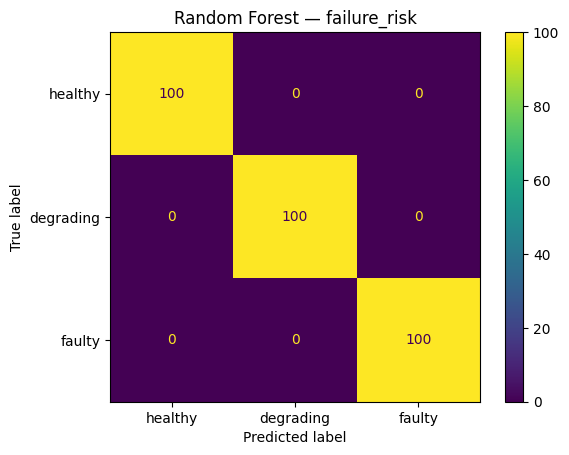

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_model.fit(X_train, y_train)
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)
y_prob_test = rf_model.predict_proba(X_test)

print("The training accuracy of the model is: ", accuracy_score(y_train, y_pred_train))
print("The test accuracy of the model is: ", accuracy_score(y_test, y_pred_test))
print("The f1 score of the model is: ", f1_score(y_test, y_pred_test, average="weighted"))
print("The roc_auc score of the model is: ", roc_auc_score(y_test, y_prob_test, multi_class='ovr', average='weighted'))
feature_names = ['vout_std', 'il_std', 'vout_pp', 'il_pp', 'vout_mean', 'il_mean']
importances = pd.Series(rf_model.feature_importances_, index=feature_names)
print(importances.sort_values(ascending=False))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=['healthy', 'degrading', 'faulty']
)
plt.title("Random Forest — failure_risk")
plt.show()

In [10]:
import joblib
joblib.dump(rf_model, '../ml/rf_model.pkl')

['../ml/rf_model.pkl']